## End-to-End Hybrid Knowledge Graph Pipeline

This notebook implements **a working, end-to-end pipeline on real data**:

1. **Load real radiology reports** from a public Hugging Face dataset  
   (e.g., `itsanmolgupta/mimic-cxr-dataset`).

2. **Extract entities and relations** using an **actual model**  
   (RadGraph-style DYGIE++ inference).

3. **Constrain the schema** to:
   - **Entity types:** `ANATOMY`, `OBSERVATION`  
     *(measurement entities excluded from ontology grounding)*
   - **Relation types:** all RadGraph-predicted relations  
     (e.g., `LOCATED_AT`, `MODIFY`)

4. **Map extracted mentions to UMLS CUIs** using a  
   **deterministic MRCONSO-based exact-matching pipeline**  
   *(no fuzzy matching or confidence thresholds)*.

5. **Build a Hybrid Knowledge Graph**:
   - **`V_prior`:** ontology-anchored concept nodes via UMLS CUIs  
     *(semantic reference space)*
   - **`V_data`:** instance nodes from extracted findings connected by RadGraph relations

6. **Export Phase I artifacts**  
   (entity–CUI mappings and graph structures) for downstream training.


In [1]:
# Suppress DeprecationWarning from jupyter_client and related libraries
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="_distutils_hack")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="radgraph")

import os, re, json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional


## 1) Load a real radiology report dataset

We'll use a public dataset on Hugging Face.

Default: `X-iZhang/MIMIC-CXR-RRG`



In [2]:
import os
from huggingface_hub import snapshot_download

def download_subset(
    repo_id: str,
    save_dir: str,
    patterns: list[str],
    repo_type: str = "dataset",
):
    """
    Download only the files matching `patterns` from a HF dataset repo.

    """
    os.makedirs(save_dir, exist_ok=True)

    local_path = snapshot_download(
        repo_id=repo_id,
        repo_type=repo_type,
        local_dir=save_dir,
        local_dir_use_symlinks=False,
        allow_patterns=patterns,   # key: only download what matches these
    )
    print(f"Downloaded to: {local_path}")

if __name__ == "__main__":
    REPO = "X-iZhang/MIMIC-CXR-RRG"
    OUT  = "MIMIC-CXR-RRG_small"   # <-- change this

    # ---- Choose ONE of these pattern sets ----

    # A) Only findings_section folder (~7.52 GB)
    # patterns = ["findings_section/*", "README.md", ".gitattributes"]

    # B) Only impression_section folder (~7.5 GB-ish)
    patterns = ["impression_section/*", "README.md", ".gitattributes"]

    # C) Only 1 shard from findings_section (~471 MB)
    # patterns = ["findings_section/test-00000-of-00016.parquet", "README.md"]

    # D) First 2 shards from impression_section and 1 from findings (~< 1 GB)
    # patterns = [
    #     "findings_section/test-00000-of-00016.parquet",
    #     "impression_section/test-00000-of-00016.parquet",
    #     "impression_section/test-00001-of-00016.parquet",
    #     "README.md"
    # ]

    download_subset(REPO, OUT, patterns)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Downloaded to: /content/MIMIC-CXR-RRG_small


In [3]:
import os
from datasets import load_dataset

OUT  = "MIMIC-CXR-RRG_small"

# Load a specific subset (e.g., findings_section)
# ds_findings = load_dataset(OUT, name="findings_section", split="test", verification_mode="no_checks")

ds_impressions = load_dataset(
    "parquet", # Specify the file format loader
    data_files=os.path.join(OUT, "impression_section", "*.parquet"), # Path to the parquet files with a glob pattern
    split="train",
    verification_mode="no_checks"
)

# View sample
print(ds_impressions[0]["impression_section"])

In comparison to ___, no relevant change is seen. Old right rib fracture. Known COPD. Mild overinflation. No pneumonia, no pleural effusions, no pulmonary edema.


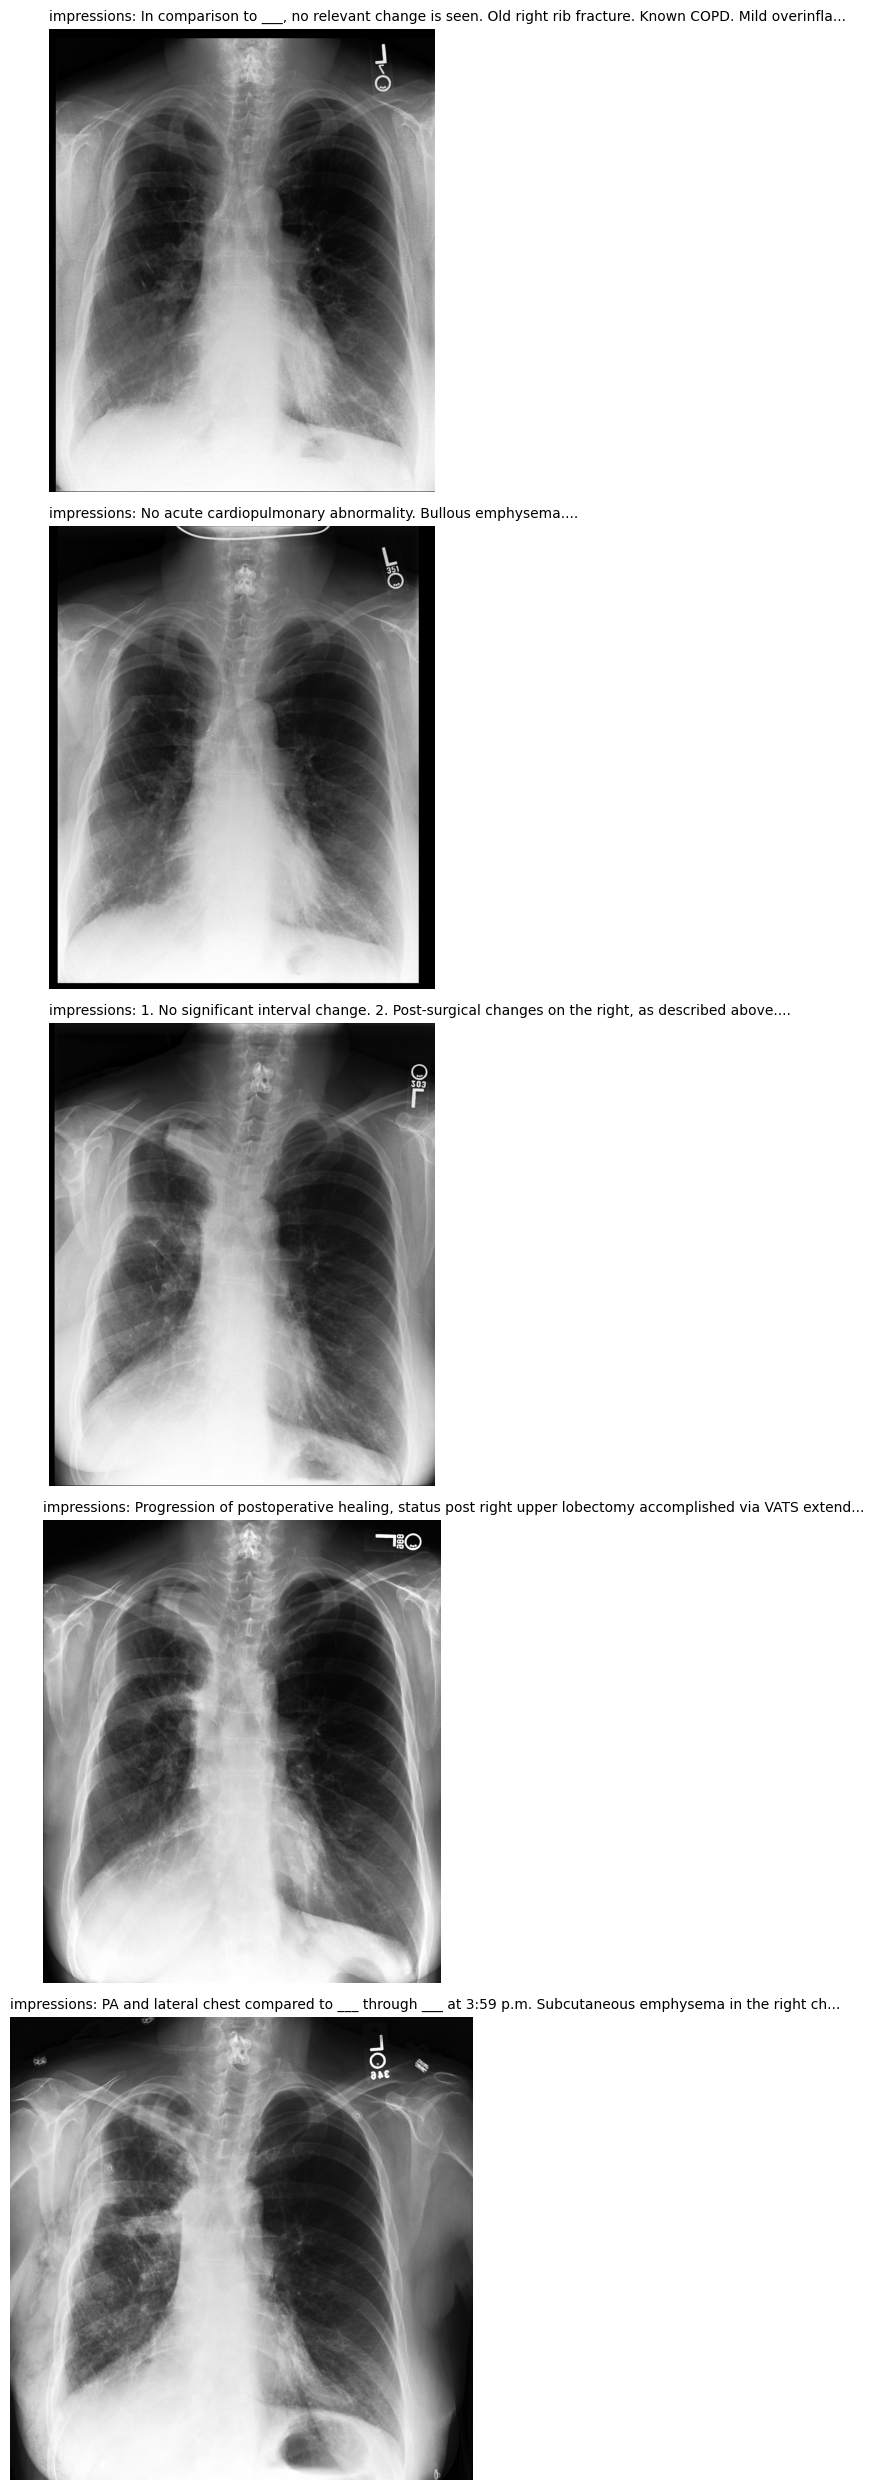

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def display_images_and_impressions(dataset, num_images=5):
    plt.figure(figsize=(15, 5 * num_images)) # Adjust figure size for vertical layout
    for i in range(min(num_images, len(dataset))):
        image = dataset[i]["main_image"]
        impressions = dataset[i]["impression_section"]

        ax = plt.subplot(num_images, 1, i + 1)
        ax.imshow(image, cmap='gray') # Assuming images are grayscale; adjust if RGB
        ax.set_title(f"impressions: {impressions[:100]}...", fontsize=10, loc='left', wrap=True) # Truncate long impressions
        ax.axis('off') # Hide axes
    plt.tight_layout()
    plt.show()

# Call the function with ds_impressions (assuming it's already loaded)
display_images_and_impressions(ds_impressions, num_images=5)

In [4]:
import pandas as pd

# Convert ds_findings to a pandas DataFrame
# df_findings = ds_findings.to_pandas()

# Convert ds_impressions to a pandas DataFrame
df_impressions = ds_impressions.to_pandas()




In [ ]:
print("Exploring ds_findings (DataFrame):")
print("Head:")
df_findings.head()

In [ ]:
print("\nInfo:")
df_findings.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 23 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   dicom_id                                    154 non-null    object
 1   study_id                                    154 non-null    object
 2   subject_id                                  154 non-null    object
 3   main_image                                  154 non-null    object
 4   findings_section                            154 non-null    object
 5   impression_section                          114 non-null    object
 6   indication_section                          87 non-null     object
 7   comparison_section                          66 non-null     object
 8   technique_section                           58 non-null     object
 9   history_section                             59 non-null     object
 10  examination_section

In [ ]:
print("\n\nExploring ds_impressions (DataFrame):")
print("Head:")
df_impressions.head()




Exploring ds_impressions (DataFrame):
Head:


,dicom_id,study_id,subject_id,main_image,findings_section,impression_section,indication_section,comparison_section,technique_section,history_section,...,PerformedProcedureStepDescription,ViewPosition,Rows,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,view
0,7558ad38-de530501-5c2ff2a1-d74fe121-ba0cf77a,56587463,19991135,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,None,"In comparison to ___, no relevant change is se...",___ year old woman with severe COPD now with d...,None,None,None,...,CHEST (PA AND LAT),PA,3056,2544,21300519,154514.703,CHEST (PA AND LAT),postero-anterior,Erect,frontal
1,1b02ffa5-a6da06e3-9063b9ef-5e540245-c18323b5,54742755,19991135,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Heart size is borderline enlarged but unchange...,No acute cardiopulmonary abnormality. Bullous ...,History: ___F with worsening dyspnea in settin...,"___ chest radiograph, ___ chest CT 8",Chest PA and lateral,None,...,CHEST (PA AND LAT),PA,3056,2544,21290925,130348.0,CHEST (PA AND LAT),postero-anterior,Erect,frontal
2,7cdd0c6e-d0263417-262f1fce-bd3d2712-99409e00,51777681,19991135,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,PA and lateral radiographs of the chest were a...,1. No significant interval change. 2. Post-sur...,"Pain, redness, and slight swelling at right ch...",Chest radiograph from ___.,None,None,...,CHEST (PA AND LAT),PA,3056,2544,21260930,133727.093,CHEST (PA AND LAT),postero-anterior,Erect,frontal
3,a8c08cbf-15ac0dac-b76a40a0-dab826c7-18015767,50286241,19991135,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,PA and lateral chest views have been obtained ...,"Progression of postoperative healing, status p...",___-year-old female patient with history of 40...,None,None,None,...,None,PA,2022,1736,21260926,103050.0,CHEST (PA AND LAT),postero-anterior,Erect,frontal
4,4998e40c-698af874-8c293856-85757f55-1a4817e4,57096024,19991135,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,None,PA and lateral chest compared to ___ through _...,None,None,None,Right VATS converted to thoracotomy for right ...,...,None,PA,2022,2022,21260914,185446.0,CHEST (PA AND LAT),postero-anterior,Erect,frontal


In [ ]:
print("\nInfo:")
df_impressions.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 23 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   dicom_id                                    294 non-null    object
 1   study_id                                    294 non-null    object
 2   subject_id                                  294 non-null    object
 3   main_image                                  294 non-null    object
 4   findings_section                            221 non-null    object
 5   impression_section                          294 non-null    object
 6   indication_section                          180 non-null    object
 7   comparison_section                          136 non-null    object
 8   technique_section                           103 non-null    object
 9   history_section                             111 non-null    object
 10  examination_section

In [5]:
# counts
n_rows = len(df_impressions)
n_patients = df_impressions["subject_id"].nunique()
n_studies = df_impressions["study_id"].nunique()
n_dicoms = df_impressions["dicom_id"].nunique()

print(n_rows, n_patients, n_studies, n_dicoms)

# how many images per study?
img_per_study = df_impressions.groupby("study_id")["dicom_id"].nunique().describe()



1905 223 1704 1905


In [8]:
img_per_study

,dicom_id
count,1704.000000
mean,1.117958
std,0.353898
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000



### 1.1 Sample a batch (to form `V_data`)

We’ll build a batch-specific instance graph from a subset of reports.


In [6]:
def clean_report(t):
    if not isinstance(t, str):
        return ""
    t = t.replace("___", " ")
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_impressions["impression_clean"] = df_impressions["impression_section"].apply(clean_report)
df_impressions["findings_clean"]   = df_impressions["findings_section"].apply(clean_report)


In [7]:
df_imp = df_impressions[df_impressions["impression_clean"].str.len() > 0].copy()

In [8]:
study_df = (
    df_imp.groupby("study_id", as_index=False)
      .agg({
          "subject_id": "first",
          "impression_clean": "first",
          "findings_clean": "first",
          "dicom_id": lambda x: list(pd.unique(x)),
          "view": lambda x: list(pd.unique(x)),
          "ViewPosition": lambda x: list(pd.unique(x)),
      })
)


In [ ]:
study_df.head()

,study_id,subject_id,impression_clean,findings_clean,dicom_id,view,ViewPosition
0,50010466,19061282,No evidence of acute cardiopulmonary process.,PA and lateral views of the chest are compared...,[144f46e1-630ba5e3-82d84674-9f0575c5-6017bdd1],[frontal],[AP]
1,50010747,13896515,"In comparison with the study of , there again ...",,[77e614cb-6c987153-793f83ce-20c1f507-f6a49f49],[frontal],[AP]
2,50014127,18835687,"Vague bibasilar opacities, which may represent...",Frontal view of the chest was obtained. A righ...,[73da0836-553a87de-58ef0562-f9c31de6-c47927ac],[frontal],[AP]
3,50016102,15131736,Cardiomegaly with hilar congestion and mild pu...,AP portable upright view of the chest. Evaluat...,[b57face8-df2c3c57-2a99e6b1-4919f774-c8c3e93c],[frontal],[AP]
4,50016413,18487334,Pacemaker leads terminate in right atrium and ...,,[edf64680-6038da78-f6693f72-535ac2bb-feee4c8b],[frontal],[AP]


In [9]:
def choose_best_row(g):
    # score views
    def score(row):
        vp = str(row.get("ViewPosition", "")).upper()
        v  = str(row.get("view", "")).lower()
        s = 0
        if "PA" in vp: s += 3
        if "AP" in vp: s += 2
        if v == "frontal": s += 2
        if "LAT" in vp or v == "lateral": s -= 1
        return s
    g = g.copy()
    g["__score"] = g.apply(score, axis=1)
    return g.sort_values("__score", ascending=False).iloc[0]

# Changed drop=True to drop=False to retain 'study_id' as a column
canonical = df_imp.groupby("study_id", group_keys=False).apply(choose_best_row, include_groups=False).reset_index(drop=False)

In [ ]:
canonical.head()

,dicom_id,study_id,subject_id,main_image,findings_section,impression_section,indication_section,comparison_section,technique_section,history_section,...,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,view,impression_clean,findings_clean,__score
0,f4a818e5-89d51e2d-9f478ecb-8774a1bf-739673b3,50043351,19720782,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,There is a right pleural effusion which is unc...,"1. Subtle left lower lobe opacity, which may r...",None,Comparison is made with CTA chest from ___.,None,"Hypoxia, dyspnea.",...,2544,21820316,130522.906,CHEST (PORTABLE AP),antero-posterior,Erect,frontal,"1. Subtle left lower lobe opacity, which may r...",There is a right pleural effusion which is unc...,4
1,a8c08cbf-15ac0dac-b76a40a0-dab826c7-18015767,50286241,19991135,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,PA and lateral chest views have been obtained ...,"Progression of postoperative healing, status p...",___-year-old female patient with history of 40...,None,None,None,...,1736,21260926,103050.0,CHEST (PA AND LAT),postero-anterior,Erect,frontal,"Progression of postoperative healing, status p...",PA and lateral chest views have been obtained ...,5
2,65275408-6db6d9a9-13c023c8-a6a96579-434dee3d,50371697,19720782,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Portable AP upright chest radiograph obtained....,Stable right hilar prominence and right pleura...,None,None,None,"Hypoxia, question pneumonia.",...,2544,21810326,164917.234,CHEST (PORTABLE AP),antero-posterior,Erect,frontal,Stable right hilar prominence and right pleura...,Portable AP upright chest radiograph obtained....,4
3,66607c54-01766ee9-0296b1fd-b642145d-24ea1577,50373067,19623993,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,PA and lateral views of the chest provided. Su...,No acute intrathoracic process.,___ year old woman with ili symptoms // ili cough,None,None,None,...,2544,21431114,172628.828,CHEST (PA AND LAT),postero-anterior,Erect,frontal,No acute intrathoracic process.,PA and lateral views of the chest provided. Su...,5
4,c8cfc832-b771f3f4-0862618d-c5b40b2a-86706006,50848970,19715857,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,There is mild cardiomegaly and moderate pulmon...,Moderate pulmonary edema.,"___ yo with dyspnea, please assess for flash p...",Chest radiograph from ___.,Single frontal radiograph of the chest obtained.,None,...,3056,21920520,160616.812,CHEST (PORTABLE AP),antero-posterior,None,frontal,Moderate pulmonary edema.,There is mild cardiomegaly and moderate pulmon...,4


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# counts
n_rows = len(canonical)
n_patients = canonical["subject_id"].nunique()
n_studies = canonical["study_id"].nunique()
n_dicoms = canonical["dicom_id"].nunique()

print(n_rows, n_patients, n_studies, n_dicoms)

# how many images per study?
img_per_study = canonical.groupby("study_id")["dicom_id"].nunique().describe()

1704 223 1704 1704


In [11]:

BATCH_SIZE = n_rows
SEED = 42

ds_batch = canonical.sample(n=BATCH_SIZE, random_state=SEED)
reports = [r['impression_clean'] for r in ds_batch.to_dict(orient='records')]

print("Batch size:", len(reports))


Batch size: 1704


In [ ]:
reports[0:10]

['1. Stable findings of chronic interstitial lung disease without definite evidence for superimposed process. 2. Air-fluid level in the esophagus which could be seen with known CREST syndrome. In addition, there is a cluster of small densities, possibly pill fragments, three altogether, projecting near the expected site of the gastroesophageal junction. Clinical correlation regarding any potential aspiration risk is recommended.',
 'No acute intrathoracic process.',
 'Unchanged appearance of the chest with findings of right pleural effusion, loculated and lower lobe atelectasis as well as right perihilar fibrosis is unchanged. Please refer to subsequent CTA chest for further details.',
 'with study of , there is little overall change. Again there is substantial enlargement of the cardiac silhouette with essentially normal pulmonary vasculature. This discordance suggests cardiomyopathy or possibly even pericardial effusion. No evidence of acute focal pneumonia.',
 'Repositioned right in


## 2) Ontology-guided entity & relation extraction (RadGraph-style)

We will use an **actual model** via the `radgraph` Python package (if installed).  
This package provides a DYGIE++-style RadGraph extraction model.


In [2]:
!pip install --upgrade transformers tokenizers radgraph

In [12]:
import importlib
from typing import Any, List, Dict
import transformers

# Inject all commonly missing legacy methods back into newer transformers tokenizers
try:
    from transformers.tokenization_utils_tokenizers import TokenizersBackend

    # 1. Patch encode_plus
    if not hasattr(TokenizersBackend, "encode_plus"):
        TokenizersBackend.encode_plus = lambda self, *args, **kwargs: self(*args, **kwargs)

    # 2. Patch build_inputs_with_special_tokens
    if not hasattr(TokenizersBackend, "build_inputs_with_special_tokens"):
        TokenizersBackend.build_inputs_with_special_tokens = lambda self, token_ids_0, token_ids_1=None: token_ids_0 + (token_ids_1 if token_ids_1 else [])

    # 3. Patch get_special_tokens_mask
    if not hasattr(TokenizersBackend, "get_special_tokens_mask"):
        TokenizersBackend.get_special_tokens_mask = lambda self, token_ids_0, token_ids_1=None, already_has_special_tokens=False: [0] * len(token_ids_0) + ([0] * len(token_ids_1) if token_ids_1 else [])

    # 4. Patch create_token_type_ids_from_sequences
    if not hasattr(TokenizersBackend, "create_token_type_ids_from_sequences"):
        TokenizersBackend.create_token_type_ids_from_sequences = lambda self, token_ids_0, token_ids_1=None: [0] * len(token_ids_0) + ([1] * len(token_ids_1) if token_ids_1 else [])

except ImportError:
    pass

def try_import_radgraph():
    try:
        import radgraph  # type: ignore
        if 'radgraph' in locals() or 'radgraph' in globals():
            radgraph = importlib.reload(radgraph)
        return radgraph
    except Exception as e:
        raise ImportError("radgraph is not installed or failed to import.") from e

radgraph = try_import_radgraph()

def radgraph_infer(texts: List[str]) -> List[Dict[str, Any]]:
    """Run RadGraph inference and return per-report dict outputs."""
    if hasattr(radgraph, "RadGraph"):
        model = radgraph.RadGraph(model_type="modern-radgraph-xl")
        if hasattr(model, "predict"):
            return model.predict(texts)
        if hasattr(model, "__call__"):
            return model(texts)
    if hasattr(radgraph, "infer"):
        return radgraph.infer(texts)
    raise RuntimeError("Unable to find a usable RadGraph inference entrypoint.")

# Run extraction on the batch
raw_preds = radgraph_infer(reports)

print("Got predictions for:", len(raw_preds), "reports")

Using device: cuda:0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Got predictions for: 1704 reports


In [ ]:
raw_preds

{'0': {'text': '1 . Stable findings of chronic interstitial lung disease without definite evidence for superimposed process . 2 . Air - fluid level in the esophagus which could be seen with known CREST syndrome . In addition , there is a cluster of small densities , possibly pill fragments , three altogether , projecting near the expected site of the gastroesophageal junction . Clinical correlation regarding any potential aspiration risk is recommended .',
  'entities': {'1': {'tokens': 'chronic',
    'label': 'Observation::definitely present',
    'start_ix': 5,
    'end_ix': 5,
    'relations': [['modify', '4']]},
   '2': {'tokens': 'interstitial',
    'label': 'Anatomy::definitely present',
    'start_ix': 6,
    'end_ix': 6,
    'relations': [['modify', '3']]},
   '3': {'tokens': 'lung',
    'label': 'Anatomy::definitely present',
    'start_ix': 7,
    'end_ix': 7,
    'relations': []},
   '4': {'tokens': 'disease',
    'label': 'Observation::definitely present',
    'start_ix': 8


### 2.1 Normalize outputs to triplets `(head, rel, tail)`


We’ll create:
- entity table: `{ent_id: (span_text, ent_type)}`
- triplets list: `(head_text, relation, tail_text)`

We also keep offsets if the model provides them (useful for later auditing).


In [13]:
from typing import Any

@dataclass
class ExtractedEntity:
    text: str
    etype: str
    start: Optional[int] = None
    end: Optional[int] = None

@dataclass
class ExtractedTriple:
    head: str
    rel: str
    tail: str

def normalize_radgraph_output(pred: Dict[str, Any]) -> Tuple[Dict[str, ExtractedEntity], List[ExtractedTriple]]:
    """Convert one RadGraph prediction dict into all extracted entities and relations."""
    entities: Dict[str, ExtractedEntity] = {}
    raw_relation_tuples: List[Tuple[str, str, str]] = [] # Stores (head_id, rtype_raw, tail_id)

    ent_obj = pred.get("entities", pred.get("entity", pred.get("nodes")))

    # Parse entities first, and collect raw relation tuples (head_id, rtype_raw, tail_id_raw)
    if isinstance(ent_obj, dict):
        for k, v in ent_obj.items():
            label = v.get("label") or v.get("type") or v.get("category")
            text = v.get("text") or v.get("tokens") or v.get("span") or v.get("mention")
            if isinstance(text, list):
                text = " ".join(text)
            elif not isinstance(text, str):
                text = str(text)

            entities[str(k)] = ExtractedEntity(
                text=text.strip(),
                etype=str(label).upper() if label else "UNKNOWN",
                start=v.get("start") or v.get("start_ix"),
                end=v.get("end") or v.get("end_ix"),
            )

            # Relations are nested within entities in RadGraph output
            entity_rels = v.get("relations", [])
            for r_item in entity_rels:
                if isinstance(r_item, list) and len(r_item) == 2:
                    rtype_raw = r_item[0]
                    target_entity_id_raw = r_item[1]
                    raw_relation_tuples.append((str(k), rtype_raw, str(target_entity_id_raw)))
    elif isinstance(ent_obj, list):
        for i, v in enumerate(ent_obj):
            label = v.get("label") or v.get("type") or v.get("category")
            text = v.get("text") or v.get("tokens") or v.get("span") or v.get("mention")
            if isinstance(text, list):
                text = " ".join(text)
            elif not isinstance(text, str):
                text = str(text)

            entities[str(i)] = ExtractedEntity(
                text=text.strip(),
                etype=str(label).upper() if label else "UNKNOWN",
                start=v.get("start") or v.get("start_ix"),
                end=v.get("end") or v.get("end_ix"),
            )

            entity_rels = v.get("relations", [])
            for r_item in entity_rels:
                if isinstance(r_item, list) and len(r_item) == 2:
                    rtype_raw = r_item[0]
                    target_entity_id_raw = r_item[1]
                    raw_relation_tuples.append((str(i), rtype_raw, str(target_entity_id_raw)))
    else:
        raise ValueError("Unknown entity output structure from RadGraph.")

    # Now, process collected relations using the fully populated entities dictionary
    triples: List[ExtractedTriple] = []
    def rel_type_normalize(x: Any) -> str:
        return str(x).lower().replace(" ", "_")

    for head_id, rtype_raw, tail_id in raw_relation_tuples:
        if head_id in entities and tail_id in entities: # Ensure both entities exist before creating triple
            h_ent = entities[head_id]
            t_ent = entities[tail_id]
            normalized_rtype = rel_type_normalize(rtype_raw)
            triples.append(ExtractedTriple(h_ent.text, normalized_rtype.upper(), t_ent.text))

    return entities, triples

all_entities = []
all_triples = []

for pred_id, pred_data in raw_preds.items():
    ents, trips = normalize_radgraph_output(pred_data)
    all_entities.append(ents)
    all_triples.extend(trips)

print("Total extracted triples:", len(all_triples))
print("Example triples:", all_triples[:5])

Total extracted triples: 11032
Example triples: [ExtractedTriple(head='PICC line', rel='LOCATED_AT', tail='right'), ExtractedTriple(head='Mild', rel='MODIFY', tail='cardiomegaly'), ExtractedTriple(head='left', rel='MODIFY', tail='pleural'), ExtractedTriple(head='effusion', rel='LOCATED_AT', tail='pleural'), ExtractedTriple(head='moderate', rel='MODIFY', tail='edema')]


In [ ]:
print(len(all_entities))
all_entities[0:5]

273


[{'1': ExtractedEntity(text='chronic', etype='OBSERVATION::DEFINITELY PRESENT', start=5, end=5),
  '2': ExtractedEntity(text='interstitial', etype='ANATOMY::DEFINITELY PRESENT', start=6, end=6),
  '3': ExtractedEntity(text='lung', etype='ANATOMY::DEFINITELY PRESENT', start=7, end=7),
  '4': ExtractedEntity(text='disease', etype='OBSERVATION::DEFINITELY PRESENT', start=8, end=8),
  '5': ExtractedEntity(text='superimposed process', etype='OBSERVATION::DEFINITELY ABSENT', start=13, end=14),
  '6': ExtractedEntity(text='Air - fluid level', etype='OBSERVATION::DEFINITELY PRESENT', start=18, end=21),
  '7': ExtractedEntity(text='esophagus', etype='ANATOMY::DEFINITELY PRESENT', start=24, end=24),
  '8': ExtractedEntity(text='CREST syndrome', etype='OBSERVATION::DEFINITELY PRESENT', start=31, end=32),
  '9': ExtractedEntity(text='cluster', etype='OBSERVATION::DEFINITELY PRESENT', start=40, end=40),
  '10': ExtractedEntity(text='small', etype='OBSERVATION::DEFINITELY PRESENT', start=42, end=42)

In [14]:
unique_entity_texts = set()
for triple in all_triples:
    unique_entity_texts.add(triple.head)
    unique_entity_texts.add(triple.tail)

sampled_entities = []
# all_entities is a list of dictionaries, where each dict contains entities for a single report
for report_entities in all_entities:
    for ent_id, entity_obj in report_entities.items():
        if entity_obj.text in unique_entity_texts:
            sampled_entities.append(entity_obj)

print(f"Unique entity texts from sampled triples: {len(unique_entity_texts)}")
print(f"Total sampled entities: {len(sampled_entities)}")

Unique entity texts from sampled triples: 1589
Total sampled entities: 17740


In [15]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a new graph
G_sample = nx.DiGraph()

entity_text_to_node_id = {}
node_counter = 0

for ent_obj in sampled_entities:
    node_label = ent_obj.text
    node_etype = ent_obj.etype
    if node_label not in entity_text_to_node_id:
        node_id = f"E_{node_counter}"
        entity_text_to_node_id[node_label] = node_id
        G_sample.add_node(node_id, label=node_label, etype=node_etype)
        node_counter += 1

# Add edges from all_triples
for triple in all_triples:
    head_label = triple.head
    tail_label = triple.tail
    relation_type = triple.rel

    head_node_id = entity_text_to_node_id.get(head_label)
    tail_node_id = entity_text_to_node_id.get(tail_label)

    if head_node_id and tail_node_id:
        G_sample.add_edge(head_node_id, tail_node_id, label=relation_type)

print(f"Graph created with {G_sample.number_of_nodes()} nodes and {G_sample.number_of_edges()} edges.")

Graph created with 1589 nodes and 3664 edges.


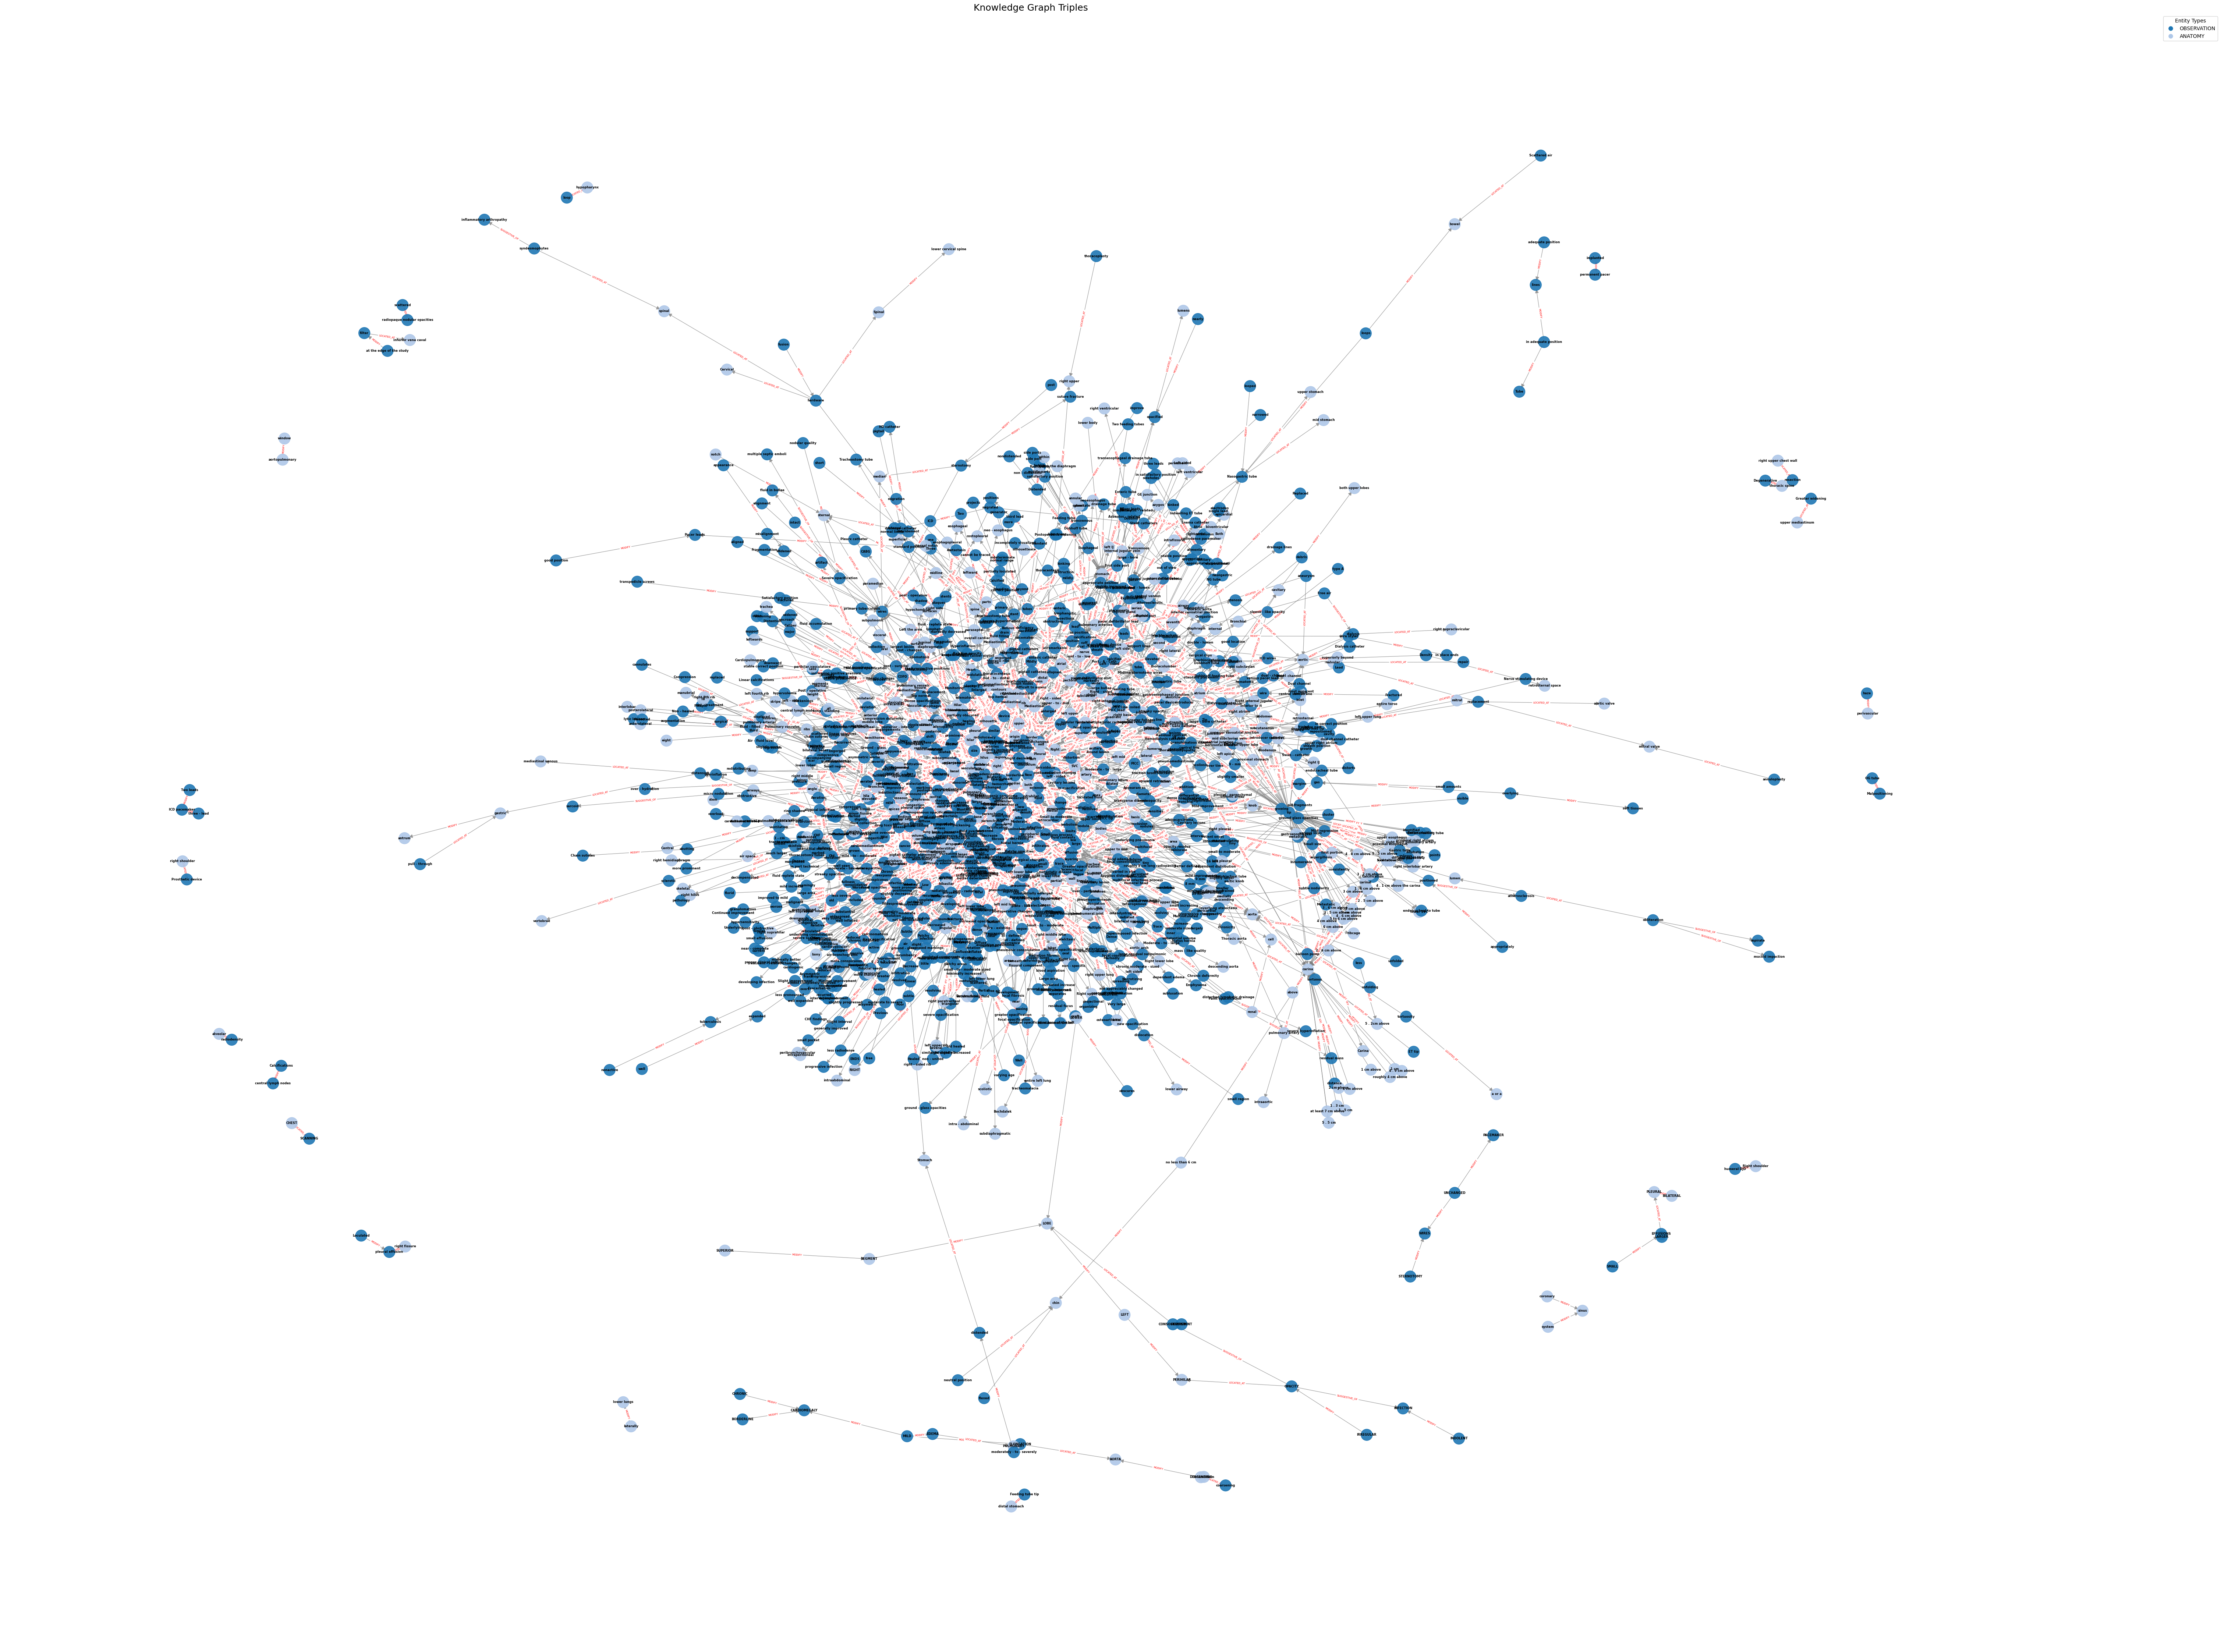

In [16]:
# Define colors for different entity types
# Using a more robust type extraction from RadGraph's label format
def get_main_etype(etype_full):
    if '::' in etype_full:
        return etype_full.split('::')[0]
    return etype_full # fallback for simpler types

entity_types = [get_main_etype(G_sample.nodes[node]['etype']) for node in G_sample.nodes()]
unique_entity_types = list(set(entity_types))

# Assign a distinct color to each unique entity type
colors = plt.colormaps.get_cmap('tab20') # Updated line to address DeprecationWarning
color_map = {etype: colors(i) for i, etype in enumerate(unique_entity_types)}

node_colors = [color_map[get_main_etype(G_sample.nodes[node]['etype'])] for node in G_sample.nodes()]
node_labels = {node: G_sample.nodes[node]['label'] for node in G_sample.nodes()}
edge_labels = nx.get_edge_attributes(G_sample, 'label')

plt.figure(figsize=(60, 45)) # Adjust figure size for better visibility

# Use a layout algorithm for positioning nodes (e.g., spring_layout for aesthetic placement)
pos = nx.spring_layout(G_sample, k=0.8, iterations=50)

# Draw nodes (reduced node size)
nx.draw_networkx_nodes(G_sample, pos, node_color=node_colors, node_size=500, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G_sample, pos, width=1.0, alpha=0.7, edge_color='gray', arrowsize=15) # Slightly reduced width and arrowsize

# Draw node labels
nx.draw_networkx_labels(G_sample, pos, labels=node_labels, font_size=6, font_weight='bold')

# Draw edge labels
nx.draw_networkx_edge_labels(G_sample, pos, edge_labels=edge_labels, font_color='red', font_size=5)

# Create a legend for entity types
legend_handles = []
for etype, color in color_map.items():
    legend_handles.append(plt.Line2D([0], [0], marker='o', color='w', label=etype,
                                       markerfacecolor=color, markersize=10))
plt.legend(handles=legend_handles, title="Entity Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Knowledge Graph Triples', size=18) # Slightly increased title size
plt.axis('off') # Hide the axes
plt.tight_layout()
plt.show()


## 3) Map extracted mentions → UMLS CUIs (Entity Disambiguation)


In [17]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [18]:
MRCONSO = f"/content/drive/MyDrive/MRCONSO.RRF"
print("MRCONSO exists:", os.path.exists(MRCONSO))


MRCONSO exists: True


In [19]:
# Flatten entity mentions across batch
all_entity_mentions = []
for ents in all_entities:
    for _, e in ents.items():
        all_entity_mentions.append(e.text)

print("Total entity mentions (batch):", len(all_entity_mentions))
print("Sample mentions:", all_entity_mentions[:10])

Total entity mentions (batch): 18149
Sample mentions: ['right', 'PICC line', 'tip', 'subclavian', 'superior vena cava', 'Placement', 'pneumothorax', 'Mild', 'cardiomegaly', 'left']


In [20]:
import re
from collections import defaultdict

# --- Base normalize (keep close to your original) ---
def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9\s\-]", "", s)  # keep hyphen
    return s

# --- Canonical surface form (still deterministic exact matching) ---
def canonicalize_surface(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"[-/]", " ", s)          # unify hyphen/slash
    s = re.sub(r"[^a-z0-9\s]", " ", s)   # drop punctuation
    s = re.sub(r"\s+", " ", s).strip()
    return s

# --- Measurement detector (exclude from mapping denominator) ---
MEAS_RE = re.compile(r"\b\d+(\.\d+)?\s*(mm|cm|m)\b")
def is_measurement_like(s: str) -> bool:
    return bool(MEAS_RE.search(s))

# --- Deterministic head candidates ---
STOP = {"no","not","without","with","of","in","on","at","the","a","an","and","or","to","for"}
LATERAL = {"left","right","bilateral","bl","b","l","r"}
SEVERITY = {"mild","mildly","moderate","moderately","severe","marked","slight","small","tiny","minimal","possible","likely"}

def head_candidates(m_norm_or_can: str):
    toks = [t for t in m_norm_or_can.split() if t and (t not in STOP)]
    toks = [t for t in toks if t not in LATERAL and t not in SEVERITY]
    cands = []
    if len(toks) >= 1: cands.append(toks[-1])
    if len(toks) >= 2: cands.append(" ".join(toks[-2:]))
    if len(toks) >= 3: cands.append(" ".join(toks[-3:]))
    # unique, longest first
    return sorted(set(cands), key=lambda x: (-len(x.split()), x))

# ---- Extract mention strings from ALL extracted entities ----
mentions_raw = []
mention_to_types = defaultdict(set)  # mention_norm -> set(types)

for ents in all_entities:
    for e in ents.values():
        if e.text and e.text.strip():
            t = e.text.strip()
            mentions_raw.append(t)
            mention_to_types[normalize_text(t)].add(e.etype)

mentions_norm = [normalize_text(m) for m in mentions_raw if normalize_text(m)]
unique_mentions = sorted(set(mentions_norm))

print("Total mentions:", len(mentions_raw))
print("Unique normalized mentions:", len(unique_mentions))
print("Sample:", unique_mentions[:20])

# ---- Build mapping keys per mention (full + canonical + head fallback) ----
mention_keys = {}   # mention_norm -> dict with keys + meta
key_to_mentions = defaultdict(list)  # key_string -> list[(mention_norm, match_type)]

for m in unique_mentions:
    m_can = canonicalize_surface(m)
    meas = is_measurement_like(m_can)

    keys = []
    # Full forms
    keys.append(("full_norm", m))
    if m_can and m_can != m:
        keys.append(("full_can", m_can))

    # Head fallbacks from canonical (more stable)
    for hc in head_candidates(m_can):
        keys.append(("head", hc))

    # De-dup keys but preserve priority order
    seen = set()
    keys_unique = []
    for ktype, k in keys:
        if k and k not in seen:
            keys_unique.append((ktype, k))
            seen.add(k)

    mention_keys[m] = {
        "canonical": m_can,
        "is_measurement": meas,
        "keys": keys_unique,   # ordered list
        "types_seen": sorted(list(mention_to_types.get(m, set()))),
    }

    for ktype, k in keys_unique:
        key_to_mentions[k].append((m, ktype))

print("Avg keys/mention:", sum(len(v["keys"]) for v in mention_keys.values()) / max(1, len(mention_keys)))
print("Measurement-like mentions:", sum(1 for v in mention_keys.values() if v["is_measurement"]))


Total mentions: 18149
Unique normalized mentions: 1677
Sample: ['1  3 cm', '1  5 cm', '1  6 cm above', '1 cm', '1 cm above', '15 mm', '16 mm', '2  5 cm', '2  5 cm above', '2  6 cm', '2  6 cm above', '2 cm above', '3  2 cm above', '3  4 cm above', '3  5 cm above', '3  6 cm above', '3 - cm', '3 cm', '3 cm above', '4  1 cm above the carina']
Avg keys/mention: 1.6547406082289804
Measurement-like mentions: 42


In [21]:
from collections import defaultdict

alias_to_candidates = defaultdict(list)  # mention_norm -> candidates (from any key)
match_trace = defaultdict(list)          # mention_norm -> list of {key, key_type, cui, sab, tty, ispref}
seen_pairs = set()
kept_rows = 0

with open(MRCONSO, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.rstrip("\n").split("|")
        if len(parts) < 15:
            continue

        cui = parts[0]
        lat = parts[1]
        ispref = parts[6]
        sab = parts[11]
        tty = parts[12]
        s = parts[14]

        if lat != "ENG":
            continue

        # IMPORTANT: use canonical surface for MRCONSO STR too
        s_key = canonicalize_surface(s)
        if s_key not in key_to_mentions:
            continue

        # This MRCONSO string matches at least one of our keys
        for mention_norm, ktype in key_to_mentions[s_key]:
            # Optional: don't even try mapping measurement mentions
            if mention_keys[mention_norm]["is_measurement"]:
                continue

            # Deduplicate (mention, cui, sab, tty)
            key = (mention_norm, cui, sab, tty)
            if key in seen_pairs:
                continue
            seen_pairs.add(key)

            cand = {
                "cui": cui,
                "sab": sab,
                "tty": tty,
                "ispref": ispref,
                "str": s,
                "matched_key": s_key,
                "matched_key_type": ktype,
            }
            alias_to_candidates[mention_norm].append(cand)
            match_trace[mention_norm].append(cand)
            kept_rows += 1

print("Exact matches found in MRCONSO rows:", kept_rows)
print("Mentions with >=1 candidate:", sum(1 for m in unique_mentions if m in alias_to_candidates), "/", len(unique_mentions))
print("Mentions eligible (non-measurement):", sum(1 for m in unique_mentions if not mention_keys[m]["is_measurement"]))


Exact matches found in MRCONSO rows: 14628
Mentions with >=1 candidate: 1412 / 1677
Mentions eligible (non-measurement): 1635


In [22]:
TOP_K = 5
USE_MRSTY_FILTER = False
SAB_PREFERENCE = ["SNOMEDCT_US", "RXNORM", "MSH"]  # or None

KEYTYPE_PRIORITY = {"full_norm": 0, "full_can": 1, "head": 2}

def rank_candidate(c):
    # 0) Prefer direct/full matches over head fallback
    ktype_rank = KEYTYPE_PRIORITY.get(c.get("matched_key_type", "head"), 9)

    # 1) Preferred term in source
    ispref_rank = 0 if c.get("ispref") == "Y" else 1

    # 2) Prefer certain SABs (optional)
    sab_rank = 999
    if SAB_PREFERENCE is not None:
        sab = c.get("sab")
        if sab in SAB_PREFERENCE:
            sab_rank = SAB_PREFERENCE.index(sab)
    else:
        sab_rank = 0

    # 3) Mild TTY preference
    tty = c.get("tty", "")
    tty_rank = 0 if tty in {"PT", "PN", "HT", "MH"} else 1

    # 4) Stable tie-breakers
    return (ktype_rank, ispref_rank, sab_rank, tty_rank, c.get("sab", ""), c.get("tty", ""), c.get("cui", ""))

def apply_mrsty_filter(cui: str, target: str) -> bool:
    if not USE_MRSTY_FILTER:
        return True
    # tuis = cui_to_tuis.get(cui, set())
    # if target == "ANATOMY":
    #     return len(tuis & ANATOMY_TUIS) > 0
    # if target == "OBSERVATION":
    #     return len(tuis & OBSERVATION_TUIS) > 0
    # return True

mention2cui = {}

for m in unique_mentions:
    # measurements are excluded deterministically
    if mention_keys[m]["is_measurement"]:
        mention2cui[m] = {
            "best_cui": None,
            "candidates": [],
            "types_seen": mention_keys[m]["types_seen"],
            "excluded_reason": "measurement_like",
        }
        continue

    cands = alias_to_candidates.get(m, [])
    types_here = mention_keys[m]["types_seen"]

    filtered = []
    for c in cands:
        cui = c["cui"]
        ok = True
        if types_here:
            ok = any(apply_mrsty_filter(cui, t) for t in types_here)
        if ok:
            filtered.append(c)

    filtered.sort(key=rank_candidate)
    top = filtered[:TOP_K]
    best = top[0]["cui"] if top else None

    mention2cui[m] = {
        "best_cui": best,
        "candidates": top,
        "types_seen": types_here,
        "excluded_reason": None,
    }

eligible = sum(1 for m in unique_mentions if not mention_keys[m]["is_measurement"])
mapped = sum(1 for m, v in mention2cui.items() if (not mention_keys[m]["is_measurement"]) and (v["best_cui"] is not None))

print("Mapped (eligible only):", mapped, "/", eligible)
print("Mapped (including measurements):", sum(1 for v in mention2cui.values() if v["best_cui"] is not None), "/", len(mention2cui))
print("Example mapped:", next((k, v) for k, v in mention2cui.items() if v["best_cui"] is not None))


Mapped (eligible only): 1412 / 1635
Mapped (including measurements): 1412 / 1677
Example mapped: ('abdomen', {'best_cui': 'C1281594', 'candidates': [{'cui': 'C1281594', 'sab': 'SNOMEDCT_US', 'tty': 'IS', 'ispref': 'Y', 'str': 'Abdomen', 'matched_key': 'abdomen', 'matched_key_type': 'full_norm'}, {'cui': 'C1508499', 'sab': 'SNOMEDCT_US', 'tty': 'OAP', 'ispref': 'Y', 'str': 'Abdomen', 'matched_key': 'abdomen', 'matched_key_type': 'full_norm'}, {'cui': 'C0000726', 'sab': 'CHV', 'tty': 'PT', 'ispref': 'Y', 'str': 'abdomen', 'matched_key': 'abdomen', 'matched_key_type': 'full_norm'}, {'cui': 'C0000726', 'sab': 'MTH', 'tty': 'PN', 'ispref': 'Y', 'str': 'Abdomen', 'matched_key': 'abdomen', 'matched_key_type': 'full_norm'}, {'cui': 'C0230168', 'sab': 'NCI', 'tty': 'PT', 'ispref': 'Y', 'str': 'Abdomen', 'matched_key': 'abdomen', 'matched_key_type': 'full_norm'}], 'types_seen': ['ANATOMY::DEFINITELY PRESENT'], 'excluded_reason': None})


In [23]:
entities_with_cui_per_report = []

for ents in all_entities:
    enriched = {}
    for ent_id, ent in ents.items():
        m = normalize_text(ent.text)
        info = mention2cui.get(m, {"best_cui": None, "candidates": [], "types_seen": []})
        enriched[ent_id] = {
            "text": ent.text,
            "etype": ent.etype,
            "start": ent.start,
            "end": ent.end,
            "cui": info["best_cui"],
            "cui_candidates": info["candidates"],  # list of dicts (cui, sab, tty, ispref, str)
        }
    entities_with_cui_per_report.append(enriched)

print("Enriched entities for report[0]:", len(entities_with_cui_per_report[0]))
print("Sample entity:", list(entities_with_cui_per_report[0].items())[:1])


Enriched entities for report[0]: 15
Sample entity: [('1', {'text': 'right', 'etype': 'ANATOMY::DEFINITELY PRESENT', 'start': 8, 'end': 8, 'cui': 'C0205090', 'cui_candidates': [{'cui': 'C0205090', 'sab': 'CHV', 'tty': 'PT', 'ispref': 'Y', 'str': 'right', 'matched_key': 'right', 'matched_key_type': 'full_norm'}, {'cui': 'C1552823', 'sab': 'HL7V3.0', 'tty': 'PT', 'ispref': 'Y', 'str': 'right', 'matched_key': 'right', 'matched_key_type': 'full_norm'}, {'cui': 'C0444532', 'sab': 'HPO', 'tty': 'PT', 'ispref': 'Y', 'str': 'Right', 'matched_key': 'right', 'matched_key_type': 'full_norm'}, {'cui': 'C0205090', 'sab': 'MTH', 'tty': 'PN', 'ispref': 'Y', 'str': 'Right', 'matched_key': 'right', 'matched_key_type': 'full_norm'}, {'cui': 'C0205090', 'sab': 'CCPSS', 'tty': 'MP', 'ispref': 'Y', 'str': 'RIGHT', 'matched_key': 'right', 'matched_key_type': 'full_norm'}]})]


In [24]:
coverage = []
for m, info in mention2cui.items():
    cands = info.get("candidates", [])
    coverage.append({
        "mention": m,
        "canonical": mention_keys[m]["canonical"],
        "types_seen": ",".join(info.get("types_seen", [])),
        "is_measurement": mention_keys[m]["is_measurement"],
        "excluded_reason": info.get("excluded_reason"),
        "mapped": info["best_cui"] is not None,
        "best_cui": info["best_cui"],
        "num_candidates": len(cands),
        "top_sab": (cands[0]["sab"] if cands else None),
        "top_tty": (cands[0]["tty"] if cands else None),
        "top_match_type": (cands[0].get("matched_key_type") if cands else None),
        "top_matched_key": (cands[0].get("matched_key") if cands else None),
    })

df_cov = pd.DataFrame(coverage)

print("Coverage summary (all mentions):")
print(df_cov["mapped"].value_counts(dropna=False))

print("\nCoverage summary (eligible only, i.e., excluding measurement-like):")
eligible_df = df_cov[df_cov["is_measurement"] == False]
print(eligible_df["mapped"].value_counts(dropna=False))




Coverage summary (all mentions):
mapped
True     1412
False     265
Name: count, dtype: int64

Coverage summary (eligible only, i.e., excluding measurement-like):
mapped
True     1412
False     223
Name: count, dtype: int64


In [ ]:
display(df_cov.head(30))

,mention,canonical,types_seen,is_measurement,excluded_reason,mapped,best_cui,num_candidates,top_sab,top_tty,top_match_type,top_matched_key
0,2 cm above,2 cm above,ANATOMY::MEASUREMENT::DEFINITELY PRESENT,True,measurement_like,False,None,0,None,None,None,None
1,3 2 cm above,3 2 cm above,ANATOMY::MEASUREMENT::DEFINITELY PRESENT,True,measurement_like,False,None,0,None,None,None,None
2,4 1 cm above the carina,4 1 cm above the carina,ANATOMY::MEASUREMENT::DEFINITELY PRESENT,True,measurement_like,False,None,0,None,None,None,None
3,4 8 cm above,4 8 cm above,ANATOMY::MEASUREMENT::DEFINITELY PRESENT,True,measurement_like,False,None,0,None,None,None,None
4,5 5 cm,5 5 cm,ANATOMY::MEASUREMENT::DEFINITELY PRESENT,True,measurement_like,False,None,0,None,None,None,None
5,6 cm above,6 cm above,ANATOMY::MEASUREMENT::DEFINITELY PRESENT,True,measurement_like,False,None,0,None,None,None,None
6,abdomen,abdomen,ANATOMY::DEFINITELY PRESENT,False,None,True,C1281594,5,SNOMEDCT_US,IS,full_norm,abdomen
7,abnormalities,abnormalities,OBSERVATION::DEFINITELY ABSENT,False,None,True,C0000769,3,MSH,TQ,full_norm,abnormalities
8,abnormality,abnormality,"OBSERVATION::DEFINITELY ABSENT,OBSERVATION::DE...",False,None,True,C1704258,3,MTH,PN,full_norm,abnormality
9,above,above,ANATOMY::DEFINITELY PRESENT,False,None,True,C1282910,5,SNOMEDCT_US,SY,full_norm,above


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
eligible_df = eligible_df.drop(columns=["is_measurement", "excluded_reason"])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
eligible_df.head(30)

,mention,canonical,types_seen,mapped,best_cui,num_candidates,top_sab,top_tty,top_match_type,top_matched_key
6,abdomen,abdomen,ANATOMY::DEFINITELY PRESENT,True,C1281594,5,SNOMEDCT_US,IS,full_norm,abdomen
7,abnormalities,abnormalities,OBSERVATION::DEFINITELY ABSENT,True,C0000769,3,MSH,TQ,full_norm,abnormalities
8,abnormality,abnormality,"OBSERVATION::DEFINITELY ABSENT,OBSERVATION::DE...",True,C1704258,3,MTH,PN,full_norm,abnormality
9,above,above,ANATOMY::DEFINITELY PRESENT,True,C1282910,5,SNOMEDCT_US,SY,full_norm,above
10,acute,acute,OBSERVATION::DEFINITELY ABSENT,True,C1547229,5,HL7V2.5,PT,full_norm,acute
11,acute disease,acute disease,OBSERVATION::DEFINITELY ABSENT,True,C0001314,5,SNOMEDCT_US,PT,full_norm,acute disease
12,acute findings,acute findings,OBSERVATION::DEFINITELY ABSENT,True,C2607943,2,MSH,PXQ,head,findings
13,adjacent,adjacent,"ANATOMY::DEFINITELY PRESENT,OBSERVATION::DEFIN...",True,C0205117,5,MTH,PN,full_norm,adjacent
14,aeration,aeration,OBSERVATION::DEFINITELY PRESENT,True,C2215609,1,MEDCIN,PT,full_norm,aeration
15,air,air,OBSERVATION::DEFINITELY PRESENT,True,C0001861,5,MSH,MH,full_norm,air


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



## 6) Export



```entities_with_cui_per_report```

```mention2cui```

```cui_coverage.csv```




In [26]:
import pickle, os

out_path = "/content/drive/MyDrive/KG/entities_with_cui.pkl"
os.makedirs(os.path.dirname(out_path), exist_ok=True)

with open(out_path, "wb") as f:
    pickle.dump(entities_with_cui_per_report, f)

print("Saved:", out_path)


Saved: /content/drive/MyDrive/KG/entities_with_cui.pkl


In [27]:
with open("/content/drive/MyDrive/KG/mention2cui.pkl", "wb") as f:
    pickle.dump(mention2cui, f)


In [28]:
df_cov.to_csv("/content/drive/MyDrive/KG/cui_coverage.csv", index=False)
